Image: img_002621.npy
GT instances: 8
Pred instances (GT decode): 7
Binary IoU (fg vs fg): 0.832594656198451


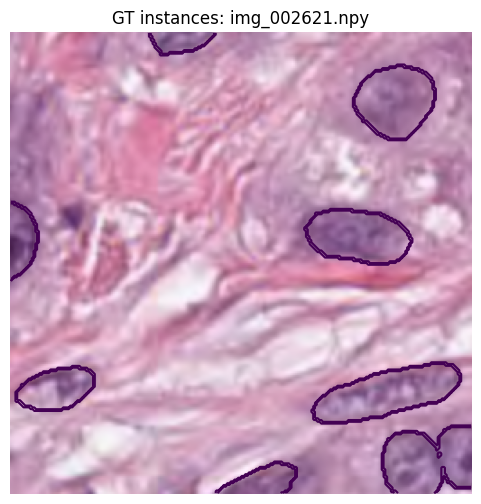

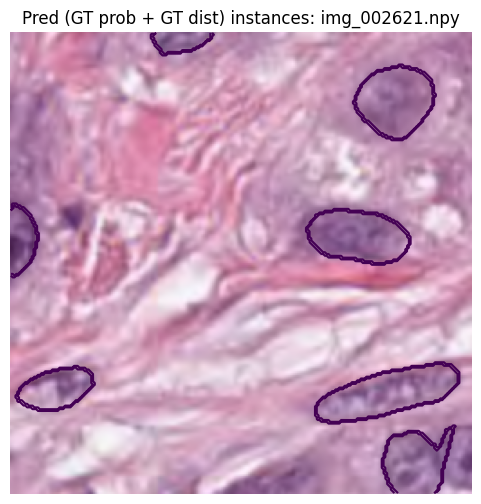

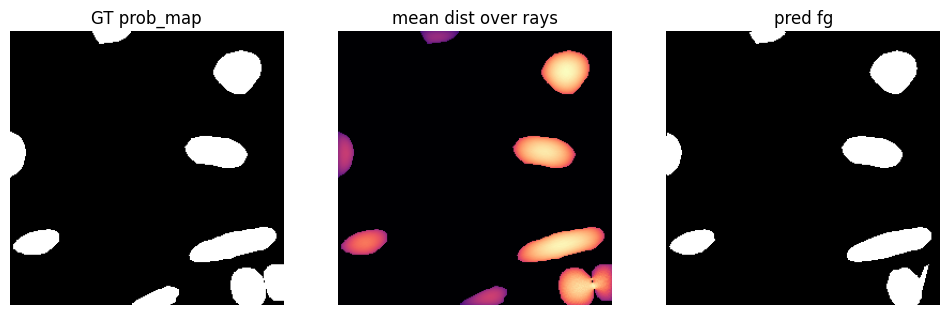

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Tes imports projet
from src.pannuke_dataset import PannukePreparedDataset
from models.stardist import stardist_decode as stardist_decode_fn

# --------------------------
# Config (adapte si besoin)
# --------------------------
DATA_ROOT = Path("data/prepared/pannuke")
SPLIT = "val"
INDEX = 0

N_NUCLEUS_CLASSES = 5     # PanNuke: types 1..5
PROB_THR = 0.5
NMS_IOU_THR = 0.3
MIN_AREA = 10
MAX_CANDIDATES = 3000
VOTE_THR = 0.5

# Si tes distances ont été normalisées au training, ici tu veux la version EN PIXELS.
# Donc, si tu as stocké des distances déjà normalisées dans dist_*.npy => remets en pixels.
DIST_SCALE = 1.0  # ex: 80.0 si tes dist_*.npy sont dans [0,1] * 80

# --------------------------
# Utils viz
# --------------------------
def show_overlay(img, inst, title=""):
    """img: (H,W,3) float[0..1], inst: (H,W) int"""
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    # contours simples
    b = np.zeros(inst.shape, dtype=bool)
    b[1:,:] |= (inst[1:,:] != inst[:-1,:])
    b[:,1:] |= (inst[:,1:] != inst[:,:-1])
    plt.contour(b.astype(float), levels=[0.5])
    plt.title(title)
    plt.axis("off")
    plt.show()

def iou_binary(a, b):
    a = a.astype(bool)
    b = b.astype(bool)
    inter = (a & b).sum()
    union = (a | b).sum()
    return float(inter) / float(union + 1e-9)

# --------------------------
# Load 1 sample (sans transform)
# --------------------------
ds = PannukePreparedDataset(
    root=DATA_ROOT,
    split=SPLIT,
    transform=None,
    return_image_name=True,
)

img_t, mask_t, types_t, name = ds[INDEX]

# img_t: (3,H,W), mask_t: (H,W)
img = img_t.permute(1,2,0).numpy()
gt_inst = mask_t.numpy().astype(np.int32)

# charge dist précomputé
stem = name.replace("img_", "").replace(".npy", "")
dist_path = DATA_ROOT / SPLIT / "targets_stardist" / f"dist_{stem}.npy"
dist_map = np.load(dist_path).astype(np.float32) * float(DIST_SCALE)   # (R,H,W)

# --------------------------
# Build GT prob + GT dist + optional GT class_prob
# --------------------------

# prob parfaite: 1 sur fg, 0 sur bg
prob_map = (gt_inst > 0).astype(np.float32)

# class_prob: (C+1,H,W) avec bg=0, classes=1..C
# si tu n'as pas types_t, mets None et ton decode doit ignorer la partie classes
class_prob = None
if types_t is not None:
    types = types_t.numpy().astype(np.int32)  # (H,W) 0..C
    C = N_NUCLEUS_CLASSES
    class_prob = np.zeros((C+1, *types.shape), dtype=np.float32)
    for c in range(C+1):
        class_prob[c] = (types == c).astype(np.float32)

# --------------------------
# Decode avec les GT
# --------------------------
pred_inst, pred_cls = stardist_decode_fn(
    prob_map=prob_map,
    dist_map=dist_map,
    class_prob=class_prob,     # None ok si ton decode le supporte
    prob_thr=PROB_THR,
    nms_iou_thr=NMS_IOU_THR,
    use_local_maxima=True,
    local_max_footprint=3,
    max_candidates=MAX_CANDIDATES,
    min_area=MIN_AREA,
    vote_thr=VOTE_THR,
)

print("Image:", name)
print("GT instances:", int(gt_inst.max()))
print("Pred instances (GT decode):", int(pred_inst.max()))
print("Binary IoU (fg vs fg):", iou_binary(pred_inst > 0, gt_inst > 0))

# --------------------------
# Visualisations
# --------------------------
show_overlay(img, gt_inst, title=f"GT instances: {name}")
show_overlay(img, pred_inst, title=f"Pred (GT prob + GT dist) instances: {name}")

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(prob_map, cmap="gray"); plt.title("GT prob_map"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(dist_map.mean(0), cmap="magma"); plt.title("mean dist over rays"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow((pred_inst>0).astype(np.float32), cmap="gray"); plt.title("pred fg"); plt.axis("off")
plt.show()
